In [2]:
import matplotlib.pyplot as plt
import numpy as np
import csv
import scipy
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq

plt.style.use('matlab.mplstyle')

In [36]:
UR = np.genfromtxt(r"S:\1.FILE\eqn\tatra-eqn-ur.csv", delimiter=',', skip_header=1)

t = UR[: , 0]/1e6
u = UR[: , 1]/30
r = UR[: , 2]/1e3

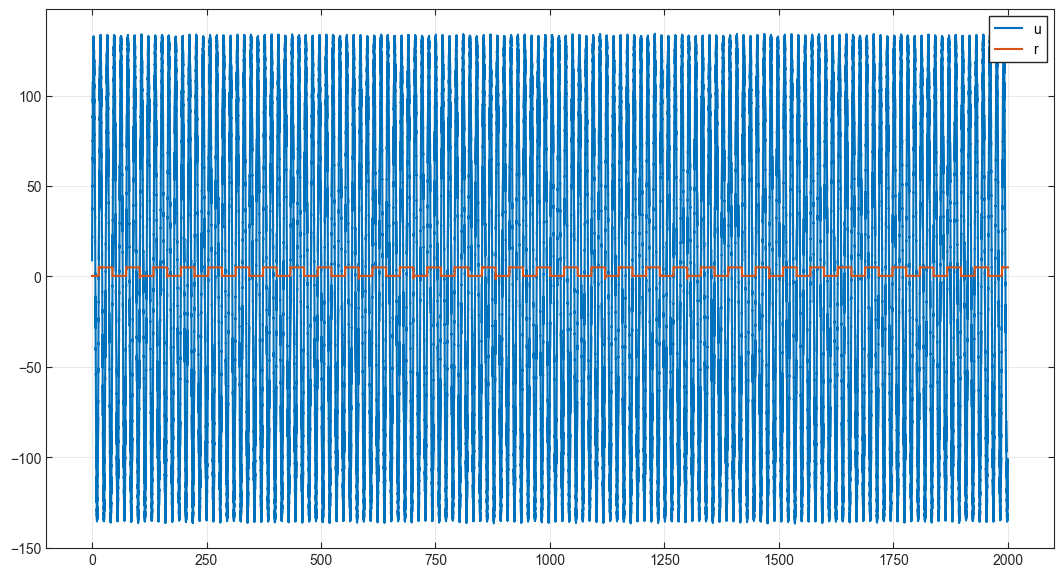

In [37]:
fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(t, u, linewidth=1.5, label="u")
ax.plot(t, r, linewidth=1.5, label="r")

#ax.set_xlim([25, 35])
#ax.set_ylim([-6, 6])
ax.grid(True)
ax.legend()

plt.show()

První sestupná hrana nalezena v čase: 44.6129 s (index 46960)
[  46960  109859  172771  235701  298668  361598  424491  487377  550259
  613132  676050  738945  801882  864797  927731  990625 1053537 1116427
 1179314 1242218 1305139 1368071 1431013 1493912 1556806 1619670 1682559
 1745465 1808375 1871308 1934253 1997204 2060141]


(990.0, 1005.0)

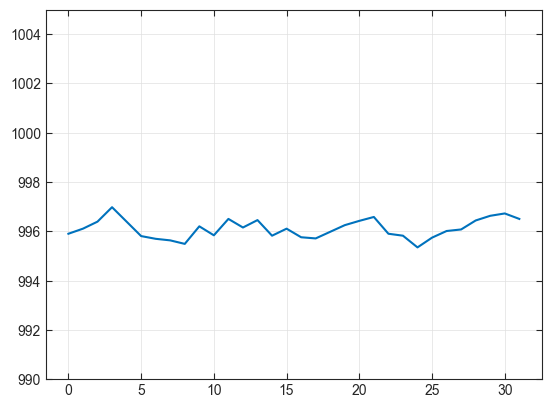

In [ ]:
d_r = np.diff(r)

# 2. Nastavení prahu a nalezení indexů (obdoba find)
prah = -2
indexy_poklesu = np.where(d_r < prah)[0]

# 3. Kontrola, zda pole není prázdné (obdoba isempty)
if indexy_poklesu.size == 0:
    raise ValueError("Žádná sestupná hrana nebyla nalezena! Zkontroluj nastavení prahu.")

rychlost = []
for i in range(len(indexy_poklesu)):
    rychlost.append((t[indexy_poklesu[i]]-t[indexy_poklesu[i-1]])*1000/60)
#print(rychlost[1:])
plt.plot(rychlost[1:])
plt.ylim(990,1005)

In [3]:
UR = np.genfromtxt(r"S:\1.FILE\eqn\tatra-eqn-ab.csv", delimiter=',', skip_header=1)

t = UR[: , 0]/1e6
a = UR[: , 1]/1e3
b = UR[: , 2]/1e3

Změřená frekvence signálu: 34253.14 Hz


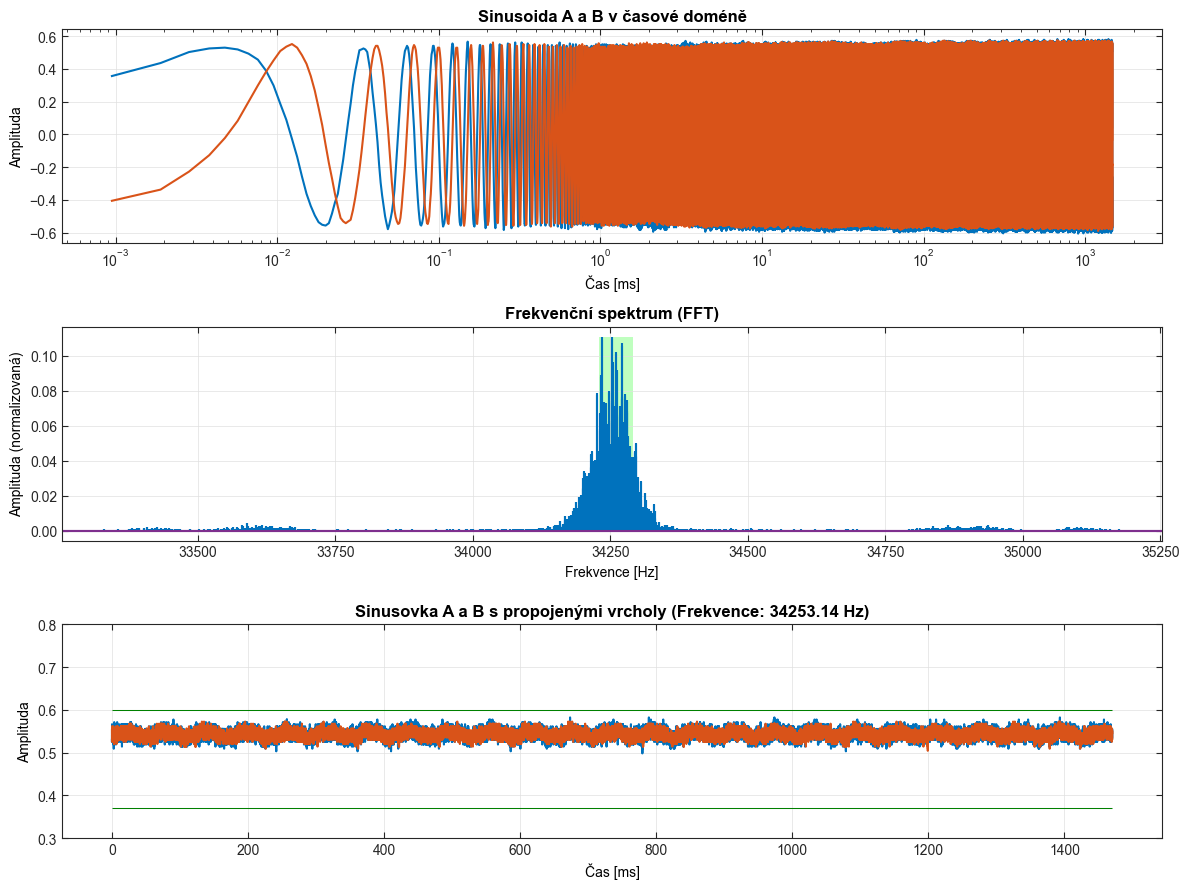

In [8]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt


def propoj_vrcholy_sinusovky(frekvence, vzorkovaci_frekvence, sinusoida, casova_osa):
    min_vzdalenost_mezi_vrcholy = int(vzorkovaci_frekvence / frekvence * 0.8) # 0.8 pro jistotu
    vrcholy_indexy, _ = find_peaks(sinusoida, distance=min_vzdalenost_mezi_vrcholy)
    # Získání hodnot časové osy a amplitudy pro nalezené vrcholy
    cas_vrcholu = casova_osa[vrcholy_indexy]
    amplituda_vrcholu = sinusoida[vrcholy_indexy]
    return cas_vrcholu, amplituda_vrcholu

def measure_frequency_of_sine_wave(signal_data, sample_rate):

    N = len(signal_data)  # Počet vzorků
    yf = fft(signal_data) # Provede rychlou Fourierovu transformaci
    xf = fftfreq(N, 1 / sample_rate) # Vypočítá frekvenční osy

    # Vezmeme pouze kladné frekvence (spektrum je symetrické)
    # Ignorujeme frekvenci 0 Hz (stejnosměrnou složku)
    positive_freq_indices = np.where(xf > 0)
    xf_positive = xf[positive_freq_indices]
    yf_positive = np.abs(yf[positive_freq_indices])

    # Najdeme index frekvence s největší amplitudou
    dominant_frequency_index = np.argmax(yf_positive)
    dominant_frequency = xf_positive[dominant_frequency_index]

    return dominant_frequency

# Výpočet frekvence

sample_rate = 1/950e-9  # Vzorkovací frekvence v Hz (např. 1000 vzorků za sekundu)
duration = t[-1]      # Doba trvání signálu v sekundách

# --- Měření frekvence ---
measured_freq = measure_frequency_of_sine_wave(a, sample_rate)
print(f"Změřená frekvence signálu: {measured_freq:.2f} Hz")
cas_vrcholu, amplituda_vrcholu = propoj_vrcholy_sinusovky(measured_freq, sample_rate, a, t)
cas_vrcholu_b, amplituda_vrcholu_b = propoj_vrcholy_sinusovky(measured_freq, sample_rate, b, t)


# --- Volitelná vizualizace ---

plt.figure(figsize=(12, 9))
plt.subplot(3, 1, 1)
plt.plot(t,a, label="sin A")
plt.plot(t, b, label="sin B")
plt.title('Sinusoida A a B v časové doméně')
plt.xlabel('Čas [ms]')
plt.ylabel('Amplituda')
plt.grid(True)
plt.xscale("log")
#plt.legend(bbox_to_anchor=(0,1,1,.1), ncol=2, mode = "expand", loc = "lower left")

# Zobrazení frekvenčního spektra

Na = len(a)
Ta = 1/sample_rate
yfa = fft(a)
xfa = fftfreq(Na, Ta)[:Na//2]

Nb = len(b)
Tb = 1/sample_rate
yfb = fft(b)
xfb = fftfreq(Nb, Tb)[:Nb//2]

plt.subplot(3, 1, 2)
plt.stem(xfa, 2.0/Na * np.abs(yfa[0:Na//2]),markerfmt="")
plt.stem(xfb, 2.0/Nb * np.abs(yfb[0:Nb//2]),markerfmt="")
plt.title('Frekvenční spektrum (FFT)')
plt.xlabel('Frekvence [Hz]')
plt.ylabel('Amplituda (normalizovaná)')
plt.grid(True)
# plt.xlim(0, measured_freq * 2) # Omezíme zobrazení na zajímavou část spektra
plt.xlim(measured_freq - 1000, measured_freq + 1000) # Omezíme zobrazení na zajímavou část spektra
#plt.vlines((34230.891+34279.019)/2,0,max( 2.0/Na * np.abs(yfa[0:Na//2])),color = 'g',lw = 34230.891-34279.019, alpha=0.25)

import matplotlib.patches as patches
obdelnik = patches.Rectangle((34230, 0), 34292-34230, max( 2.0/Na * np.abs(yfa[0:Na//2])), 
                            edgecolor='none', 
                            facecolor='lime', 
                            alpha=0.25, 
                            linewidth=1)
os = plt.gca()
os.add_patch(obdelnik)
plt.subplot(3, 1, 3)
#plt.plot(tt, a, label='Původní sinusovka')
# Spojení vrcholů čarami
plt.plot(cas_vrcholu, amplituda_vrcholu, label='Spojené vrcholy')
plt.plot(cas_vrcholu_b, amplituda_vrcholu_b, label='Spojené vrcholy')
plt.hlines(0.37,0,cas_vrcholu[-1],color = 'g',lw = 0.75)
plt.hlines(0.6,0,cas_vrcholu[-1],color = 'g',lw = 0.75)
plt.title(f'Sinusovka A a B s propojenými vrcholy (Frekvence: {measured_freq:.2f} Hz)')
plt.xlabel('Čas [ms]')
plt.ylabel('Amplituda')
#plt.legend()
plt.ylim(0.3,0.8)
plt.tight_layout()
plt.show()